In [1]:
# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim

# Data handling (already used in task a, but safe to include)
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Utilities
import pandas as pd
import itertools
import matplotlib.pyplot as plt

### Data import

In [31]:
IMG_SIZE = (64, 64) #IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_dir = "icosimal_img_class_03/data_uniform_224_224_sets/train"
val_dir = "icosimal_img_class_03/data_uniform_224_224_sets/validate"

# Transforms
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

# Datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Class names
class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']
Number of classes: 10


### a) Start from simple CNN architectures and progressively increase their complexity to show the benefit of depth

In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [5]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [6]:
class CNN_1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, num_classes)
        )

#        self.classifier = nn.Sequential(
#            nn.Flatten(),
#            nn.Linear(16 * 64 * 64, num_classes)
#        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [7]:
class CNN_2(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

#        self.classifier = nn.Sequential(
#            nn.Flatten(),
#            nn.Linear(32 * 32 * 32, 128),
#            nn.ReLU(),
#            nn.Linear(128, num_classes)
#        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [20]:
class CNN_3(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

#        self.classifier = nn.Sequential(
#            nn.Flatten(),
#            nn.Linear(64 * 16 * 16, 256),
#            nn.ReLU(),
#            nn.Linear(256, num_classes)
#        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

NEW CODE to replace upper code

In [10]:
print("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {
    "CNN_1": CNN_1(num_classes),
    "CNN_2": CNN_2(num_classes),
    "CNN_3": CNN_3(num_classes)
}

criterion = nn.CrossEntropyLoss()

results = []

for name, model in models.items():
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    print(f"\nTraining {name}...")

    best_val_acc = 0

    for epoch in range(10):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        best_val_acc = max(best_val_acc, val_acc)

        print(f"{name} | Epoch {epoch+1}/10")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

    # store final results
    results.append({
        "model": name,
        "final_train_loss": train_loss,
        "final_train_acc": train_acc,
        "final_val_loss": val_loss,
        "final_val_acc": val_acc,
        "best_val_acc": best_val_acc
    })

# -------------------------
# Create comparison table
# -------------------------
results_df = pd.DataFrame(results)

print("\n=== Model Comparison ===")
display(results_df.sort_values(by="best_val_acc", ascending=False))

cuda

Training CNN_1...
CNN_1 | Epoch 1/10
Train Loss: 2.1874, Train Acc: 0.2030
Val   Loss: 2.0912, Val   Acc: 0.2547
CNN_1 | Epoch 2/10
Train Loss: 2.0373, Train Acc: 0.2878
Val   Loss: 2.0325, Val   Acc: 0.2698
CNN_1 | Epoch 3/10
Train Loss: 1.9701, Train Acc: 0.3159
Val   Loss: 1.9508, Val   Acc: 0.3280
CNN_1 | Epoch 4/10
Train Loss: 1.9211, Train Acc: 0.3343
Val   Loss: 1.9117, Val   Acc: 0.3403
CNN_1 | Epoch 5/10
Train Loss: 1.8857, Train Acc: 0.3513
Val   Loss: 1.8800, Val   Acc: 0.3527
CNN_1 | Epoch 6/10
Train Loss: 1.8479, Train Acc: 0.3675
Val   Loss: 1.8526, Val   Acc: 0.3602
CNN_1 | Epoch 7/10
Train Loss: 1.8162, Train Acc: 0.3754
Val   Loss: 1.8194, Val   Acc: 0.3717
CNN_1 | Epoch 8/10
Train Loss: 1.7879, Train Acc: 0.3878
Val   Loss: 1.7950, Val   Acc: 0.3858
CNN_1 | Epoch 9/10
Train Loss: 1.7657, Train Acc: 0.3943
Val   Loss: 1.7640, Val   Acc: 0.3990
CNN_1 | Epoch 10/10
Train Loss: 1.7438, Train Acc: 0.4044
Val   Loss: 1.7655, Val   Acc: 0.3957

Training CNN_2...
CNN_2 

,model,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc
2,CNN_3,0.953700,0.668833,1.201228,0.590167,0.590167
1,CNN_2,1.265783,0.560042,1.323983,0.549500,0.549500
0,CNN_1,1.743794,0.404417,1.765483,0.395667,0.399000


### b) Show the importance of hyperparameter tuning.

In [11]:
learning_rates = [0.001, 0.0001]
dropout_rates = [0.0, 0.3, 0.5]
optimizers_list = ["Adam", "RMSprop"]
batch_sizes = [32, 64]

num_epochs = 5

grid = list(itertools.product(
    learning_rates,
    dropout_rates,
    optimizers_list,
    batch_sizes
))

print("Total experiments:", len(grid))
print(grid[:5])  # preview first few combinations

Total experiments: 24
[(0.001, 0.0, 'Adam', 32), (0.001, 0.0, 'Adam', 64), (0.001, 0.0, 'RMSprop', 32), (0.001, 0.0, 'RMSprop', 64), (0.001, 0.3, 'Adam', 32)]


In [12]:
class CNN_3_Tunable(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history


In [14]:
results = []
all_histories = {}

for i, (lr, dropout_rate, optimizer_name, batch_size) in enumerate(grid, start=1):
    print("\n" + "=" * 70)
    print(f"Experiment {i}/{len(grid)}")
    print(f"learning_rate={lr}, dropout={dropout_rate}, optimizer={optimizer_name}, batch_size={batch_size}")

    model = CNN_3_Tunable(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    config_name = f"lr={lr}_dropout={dropout_rate}_opt={optimizer_name}_bs={batch_size}"
    all_histories[config_name] = history

    results.append({
        "learning_rate": lr,
        "dropout": dropout_rate,
        "optimizer": optimizer_name,
        "batch_size": batch_size,
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    })

results_df = pd.DataFrame(results)


Experiment 1/24
learning_rate=0.001, dropout=0.0, optimizer=Adam, batch_size=32
Epoch 1/5 | Train Loss: 1.9748, Train Acc: 0.2925 | Val Loss: 1.7640, Val Acc: 0.3718
Epoch 2/5 | Train Loss: 1.6127, Train Acc: 0.4365 | Val Loss: 1.4846, Val Acc: 0.4743
Epoch 3/5 | Train Loss: 1.4523, Train Acc: 0.4909 | Val Loss: 1.4011, Val Acc: 0.5173
Epoch 4/5 | Train Loss: 1.3529, Train Acc: 0.5312 | Val Loss: 1.3357, Val Acc: 0.5380
Epoch 5/5 | Train Loss: 1.2604, Train Acc: 0.5620 | Val Loss: 1.2666, Val Acc: 0.5643

Experiment 2/24
learning_rate=0.001, dropout=0.0, optimizer=Adam, batch_size=64
Epoch 1/5 | Train Loss: 1.9571, Train Acc: 0.3017 | Val Loss: 1.7283, Val Acc: 0.3990
Epoch 2/5 | Train Loss: 1.6311, Train Acc: 0.4260 | Val Loss: 1.5268, Val Acc: 0.4618
Epoch 3/5 | Train Loss: 1.4641, Train Acc: 0.4873 | Val Loss: 1.4150, Val Acc: 0.5087
Epoch 4/5 | Train Loss: 1.3512, Train Acc: 0.5272 | Val Loss: 1.3198, Val Acc: 0.5420
Epoch 5/5 | Train Loss: 1.2621, Train Acc: 0.5605 | Val Loss: 1.

In [15]:
# ---- Full sorted result table ----
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)
display(results_sorted)

# ---- Best configuration ----
best_result = results_sorted.iloc[0]

print("Best configuration:")
display(best_result.to_frame())

# ---- Pivot table / matrix view ----
pivot_table = results_df.pivot_table(
    index="optimizer",
    columns=["learning_rate", "dropout", "batch_size"],
    values="best_val_acc"
)

print("Pivot table of best validation accuracy:")
display(pivot_table)

# ---- Average result by optimizer ----
optimizer_summary = results_df.groupby("optimizer")[["best_val_acc", "final_val_acc", "final_val_loss"]].mean()
print("Average performance per optimizer:")
display(optimizer_summary)

# ---- Save results if needed ----
results_df.to_csv("cnn3_grid_search_results.csv", index=False)
print("Results saved to cnn3_grid_search_results.csv")

,learning_rate,dropout,optimizer,batch_size,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
0,0.0010,0.0,Adam,32,1.260370,0.562000,1.266586,0.564333,0.564333,1.266586
2,0.0010,0.0,RMSprop,32,1.265455,0.558667,1.296199,0.546167,0.546167,1.296199
1,0.0010,0.0,Adam,64,1.262073,0.560542,1.296098,0.543500,0.543500,1.296098
5,0.0010,0.3,Adam,64,1.368491,0.522000,1.363552,0.535333,0.535333,1.363552
7,0.0010,0.3,RMSprop,64,1.362572,0.526125,1.327602,0.530833,0.530833,1.327602
11,0.0010,0.5,RMSprop,64,1.432787,0.502208,1.358872,0.529500,0.529500,1.358872
10,0.0010,0.5,RMSprop,32,1.446425,0.498208,1.374366,0.528833,0.528833,1.374366
4,0.0010,0.3,Adam,32,1.359586,0.528667,1.367281,0.524333,0.524333,1.367281
6,0.0010,0.3,RMSprop,32,1.368153,0.523083,1.360061,0.523333,0.523333,1.360061
3,0.0010,0.0,RMSprop,64,1.305703,0.546042,1.370810,0.517833,0.517833,1.370810


Best configuration:


,0
learning_rate,0.001
dropout,0.0
optimizer,Adam
batch_size,32
final_train_loss,1.26037
final_train_acc,0.562
final_val_loss,1.266586
final_val_acc,0.564333
best_val_acc,0.564333
best_val_loss,1.266586


Pivot table of best validation accuracy:


learning_rate    0.0001                                                    \
dropout             0.0                 0.3                 0.5             
batch_size           32        64        32        64        32        64   
optimizer                                                                   
Adam           0.401167  0.389333  0.383333  0.367333  0.380667  0.359167   
RMSprop        0.348167  0.361167  0.370833  0.356333  0.361000  0.354000   

learning_rate    0.0010                                                    
dropout             0.0                 0.3                 0.5            
batch_size           32        64        32        64        32        64  
optimizer                                                                  
Adam           0.564333  0.543500  0.524333  0.535333  0.516500  0.517167  
RMSprop        0.546167  0.517833  0.523333  0.530833  0.528833  0.529500

Average performance per optimizer:


,best_val_acc,final_val_acc,final_val_loss
optimizer,,,
Adam,0.456847,0.456847,1.560439
RMSprop,0.444000,0.444000,1.590985


Results saved to cnn3_grid_search_results.csv


### c) Show models that overfit and underfit and explain the reasons for that. 

In [39]:
# =========================
# 1. SETUP
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

# Reuse your existing:
# - make_loaders(batch_size)
# - device
# - num_classes

BATCH_SIZE = 32
NUM_EPOCHS = 15


# -------------------------
# Underfitting model (too simple)
# -------------------------
class CNN_Underfit(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(8 * 32 * 32, num_classes)  # assumes 64x64 input
        )

    def forward(self, x):
        return self.model(x)


# -------------------------
# Overfitting model (too complex)
# -------------------------
class CNN_Overfit(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# -------------------------
# Shared train / evaluate
# -------------------------
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    return running_loss / total, correct / total


def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return running_loss / total, correct / total

In [40]:
# =========================
# 2. MODEL TRAINING
# =========================

criterion = nn.CrossEntropyLoss()
learning_rate = 0.001

experiments = {
    "Underfitting_Model": CNN_Underfit(num_classes),
    "Overfitting_Model": CNN_Overfit(num_classes)
}

results = []
histories = {}

for name, model in experiments.items():
    print("\n" + "=" * 70)
    print(f"Training {name}")

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"{name} | Epoch {epoch+1}/{NUM_EPOCHS} | "
            f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
        )

    histories[name] = history

    results.append({
        "model": name,
        "final_train_acc": history["train_acc"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"])
    })

results_df = pd.DataFrame(results)


Training Underfitting_Model
Underfitting_Model | Epoch 1/15 | Train Acc: 0.2617 | Val Acc: 0.3228
Underfitting_Model | Epoch 2/15 | Train Acc: 0.3354 | Val Acc: 0.3612
Underfitting_Model | Epoch 3/15 | Train Acc: 0.3547 | Val Acc: 0.3808
Underfitting_Model | Epoch 4/15 | Train Acc: 0.3652 | Val Acc: 0.3958
Underfitting_Model | Epoch 5/15 | Train Acc: 0.3742 | Val Acc: 0.3813
Underfitting_Model | Epoch 6/15 | Train Acc: 0.3757 | Val Acc: 0.3977
Underfitting_Model | Epoch 7/15 | Train Acc: 0.3840 | Val Acc: 0.4263
Underfitting_Model | Epoch 8/15 | Train Acc: 0.3901 | Val Acc: 0.4098
Underfitting_Model | Epoch 9/15 | Train Acc: 0.3982 | Val Acc: 0.3788
Underfitting_Model | Epoch 10/15 | Train Acc: 0.4007 | Val Acc: 0.4207
Underfitting_Model | Epoch 11/15 | Train Acc: 0.4038 | Val Acc: 0.4277
Underfitting_Model | Epoch 12/15 | Train Acc: 0.4131 | Val Acc: 0.4280
Underfitting_Model | Epoch 13/15 | Train Acc: 0.4087 | Val Acc: 0.4168
Underfitting_Model | Epoch 14/15 | Train Acc: 0.4111 | Va

,model,final_train_acc,final_val_acc,best_val_acc
0,Underfitting_Model,0.409833,0.4415,0.4415
1,Overfitting_Model,0.093500,0.1000,0.1000


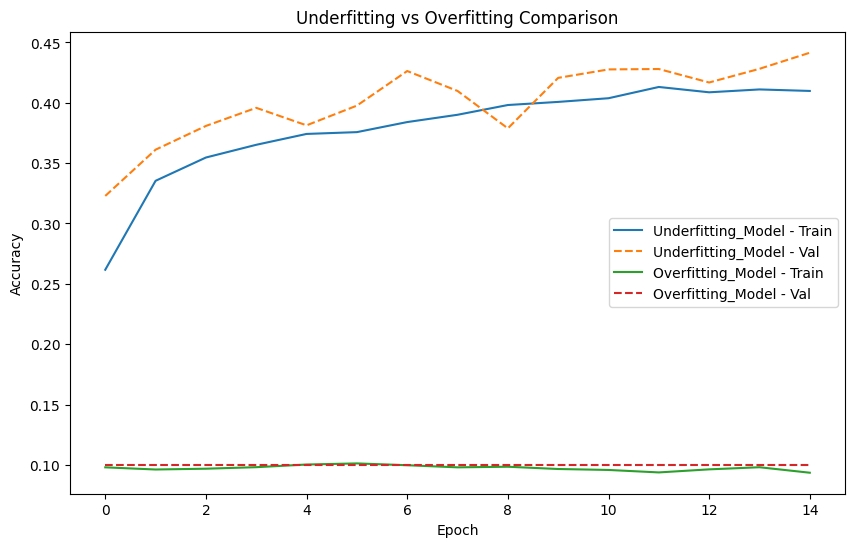

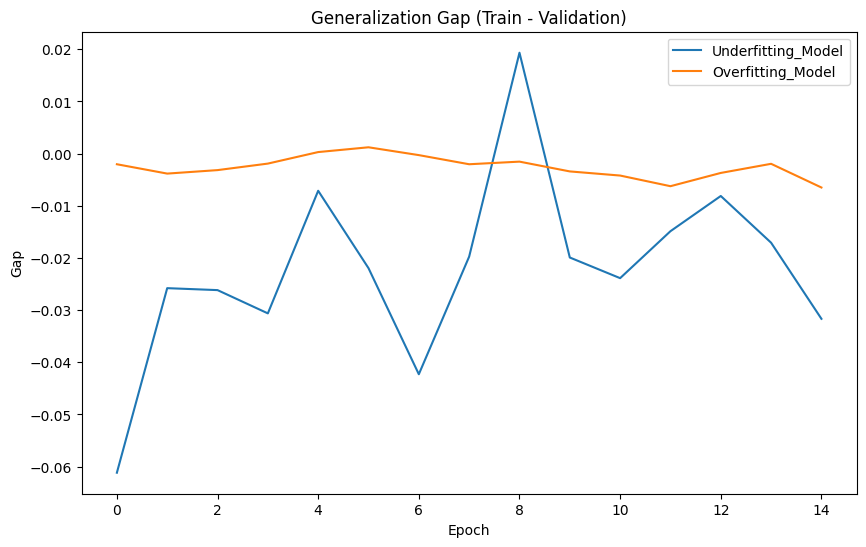

In [41]:
# =========================
# 3. EVALUATIONS
# =========================

# -------------------------
# A) Results table
# -------------------------
display(results_df.sort_values(by="best_val_acc", ascending=False))


# -------------------------
# B) Accuracy curves
# -------------------------
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["train_acc"], label=f"{name} - Train")
    plt.plot(history["val_acc"], linestyle="--", label=f"{name} - Val")

plt.title("Underfitting vs Overfitting Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# -------------------------
# C) Generalization gap
# -------------------------
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    gap = [t - v for t, v in zip(history["train_acc"], history["val_acc"])]
    plt.plot(gap, label=name)

plt.title("Generalization Gap (Train - Validation)")
plt.xlabel("Epoch")
plt.ylabel("Gap")
plt.legend()
plt.show()

### d) Experiment with regularization techniques.

In [16]:
class CNN_3_Regularized(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history

In [18]:
regularization_configs = [
    {"name": "Baseline", "dropout": 0.0, "weight_decay": 0.0},
    {"name": "Dropout", "dropout": 0.5, "weight_decay": 0.0},
    {"name": "WeightDecay", "dropout": 0.0, "weight_decay": 1e-4},
    {"name": "Dropout+WeightDecay", "dropout": 0.5, "weight_decay": 1e-4},
]

num_epochs = 10
criterion = nn.CrossEntropyLoss()

results = []
histories = {}

for config in regularization_configs:
    print("\n" + "=" * 60)
    print(f"Running: {config['name']}")
    print(f"dropout={config['dropout']}, weight_decay={config['weight_decay']}")

    model = CNN_3_Regularized(
        num_classes=num_classes,
        dropout_rate=config["dropout"]
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=config["weight_decay"]
    )

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    histories[config["name"]] = history

    results.append({
        "config": config["name"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    })

results_df = pd.DataFrame(results)


Running: Baseline
dropout=0.0, weight_decay=0.0
Epoch 1/10 | Train Loss: 2.0834, Train Acc: 0.2394 | Val Loss: 1.8337, Val Acc: 0.3525
Epoch 2/10 | Train Loss: 1.7396, Train Acc: 0.3852 | Val Loss: 1.6515, Val Acc: 0.4120
Epoch 3/10 | Train Loss: 1.5724, Train Acc: 0.4504 | Val Loss: 1.5551, Val Acc: 0.4522
Epoch 4/10 | Train Loss: 1.4455, Train Acc: 0.4955 | Val Loss: 1.4363, Val Acc: 0.5025
Epoch 5/10 | Train Loss: 1.3488, Train Acc: 0.5292 | Val Loss: 1.3540, Val Acc: 0.5287
Epoch 6/10 | Train Loss: 1.2648, Train Acc: 0.5640 | Val Loss: 1.3183, Val Acc: 0.5373
Epoch 7/10 | Train Loss: 1.1926, Train Acc: 0.5889 | Val Loss: 1.3067, Val Acc: 0.5452
Epoch 8/10 | Train Loss: 1.1246, Train Acc: 0.6103 | Val Loss: 1.3215, Val Acc: 0.5480
Epoch 9/10 | Train Loss: 1.0553, Train Acc: 0.6345 | Val Loss: 1.2768, Val Acc: 0.5627
Epoch 10/10 | Train Loss: 0.9925, Train Acc: 0.6584 | Val Loss: 1.2592, Val Acc: 0.5605

Running: Dropout
dropout=0.5, weight_decay=0.0
Epoch 1/10 | Train Loss: 2.0400,

In [19]:
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)

print("Regularization comparison:")
display(results_sorted)

Regularization comparison:


,config,dropout,weight_decay,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
1,Dropout,0.5,0.0000,1.199411,0.582500,1.215184,0.582833,0.582833,1.215184
3,Dropout+WeightDecay,0.5,0.0001,1.249701,0.567458,1.244231,0.569000,0.569000,1.244231
2,WeightDecay,0.0,0.0001,1.066389,0.632000,1.258893,0.565000,0.565000,1.258893
0,Baseline,0.0,0.0000,0.992527,0.658375,1.259232,0.560500,0.562667,1.259232


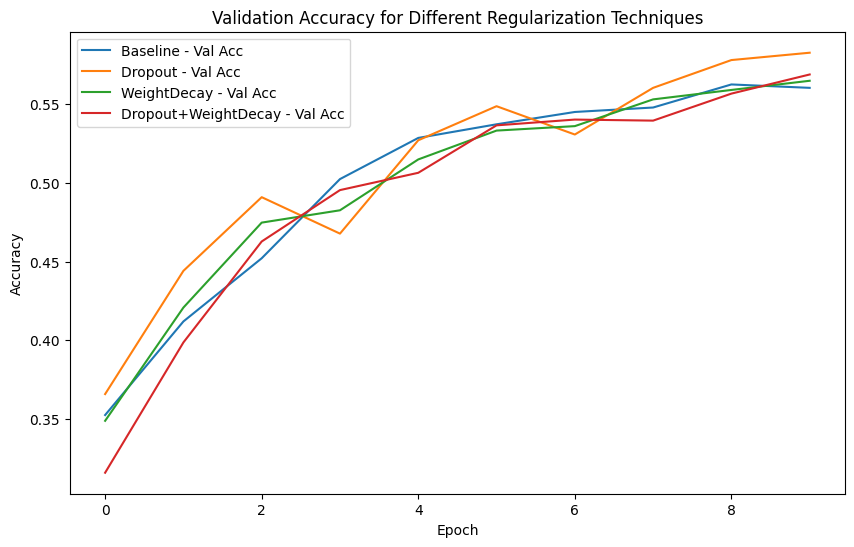

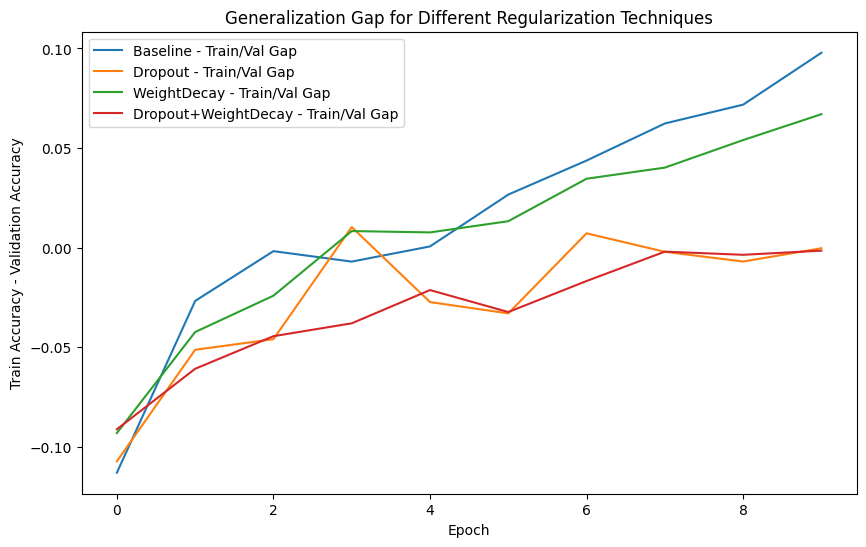

In [21]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{name} - Val Acc")

plt.title("Validation Accuracy for Different Regularization Techniques")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    gap = [train - val for train, val in zip(history["train_acc"], history["val_acc"])]
    plt.plot(gap, label=f"{name} - Train/Val Gap")

plt.title("Generalization Gap for Different Regularization Techniques")
plt.xlabel("Epoch")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.legend()
plt.show()

### e) Experiment with different optimization algorithms (e.g., Adam, RMSprop) and compare their performance.

In [22]:
optimizer_configs = [
    {"name": "Adam", "lr": 0.001},
    {"name": "RMSprop", "lr": 0.001},
    {"name": "SGD", "lr": 0.01, "momentum": 0.9}
]

num_epochs = 10

In [23]:
class CNN_3_Optim(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [24]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history


criterion = nn.CrossEntropyLoss()

results = []
histories = {}

for config in optimizer_configs:
    print("\n" + "=" * 60)
    print(f"Running optimizer: {config['name']}")

    model = CNN_3_Optim(num_classes=num_classes, dropout_rate=0.0).to(device)

    if config["name"] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    elif config["name"] == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=config["lr"])
    elif config["name"] == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=config["lr"],
            momentum=config["momentum"]
        )
    else:
        raise ValueError(f"Unsupported optimizer: {config['name']}")

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    histories[config["name"]] = history

    results.append({
        "optimizer": config["name"],
        "learning_rate": config["lr"],
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    })

results_df = pd.DataFrame(results)


Running optimizer: Adam
Epoch 1/10 | Train Loss: 1.9727, Train Acc: 0.2868 | Val Loss: 1.7205, Val Acc: 0.3862
Epoch 2/10 | Train Loss: 1.6541, Train Acc: 0.4188 | Val Loss: 1.5859, Val Acc: 0.4368
Epoch 3/10 | Train Loss: 1.4928, Train Acc: 0.4776 | Val Loss: 1.4448, Val Acc: 0.4935
Epoch 4/10 | Train Loss: 1.3776, Train Acc: 0.5193 | Val Loss: 1.4259, Val Acc: 0.4947
Epoch 5/10 | Train Loss: 1.2933, Train Acc: 0.5512 | Val Loss: 1.3250, Val Acc: 0.5358
Epoch 6/10 | Train Loss: 1.2103, Train Acc: 0.5768 | Val Loss: 1.3082, Val Acc: 0.5483
Epoch 7/10 | Train Loss: 1.1366, Train Acc: 0.6008 | Val Loss: 1.2416, Val Acc: 0.5702
Epoch 8/10 | Train Loss: 1.0790, Train Acc: 0.6257 | Val Loss: 1.2371, Val Acc: 0.5722
Epoch 9/10 | Train Loss: 1.0110, Train Acc: 0.6485 | Val Loss: 1.2293, Val Acc: 0.5818
Epoch 10/10 | Train Loss: 0.9509, Train Acc: 0.6699 | Val Loss: 1.2630, Val Acc: 0.5795

Running optimizer: RMSprop
Epoch 1/10 | Train Loss: 1.9732, Train Acc: 0.2897 | Val Loss: 1.7270, Val A

In [25]:
# ---- Sorted result table ----
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)

print("Optimizer comparison:")
display(results_sorted)

# ---- Best optimizer ----
best_result = results_sorted.iloc[0]

print("Best optimizer configuration:")
display(best_result.to_frame())

Optimizer comparison:


,optimizer,learning_rate,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
0,Adam,0.001,0.950858,0.669917,1.263013,0.5795,0.581833,1.229333
1,RMSprop,0.001,0.957922,0.670542,1.314858,0.5490,0.576500,1.240491
2,SGD,0.010,1.018487,0.644667,1.264997,0.5670,0.567000,1.264997


Best optimizer configuration:


,0
optimizer,Adam
learning_rate,0.001
final_train_loss,0.950858
final_train_acc,0.669917
final_val_loss,1.263013
final_val_acc,0.5795
best_val_acc,0.581833
best_val_loss,1.229333


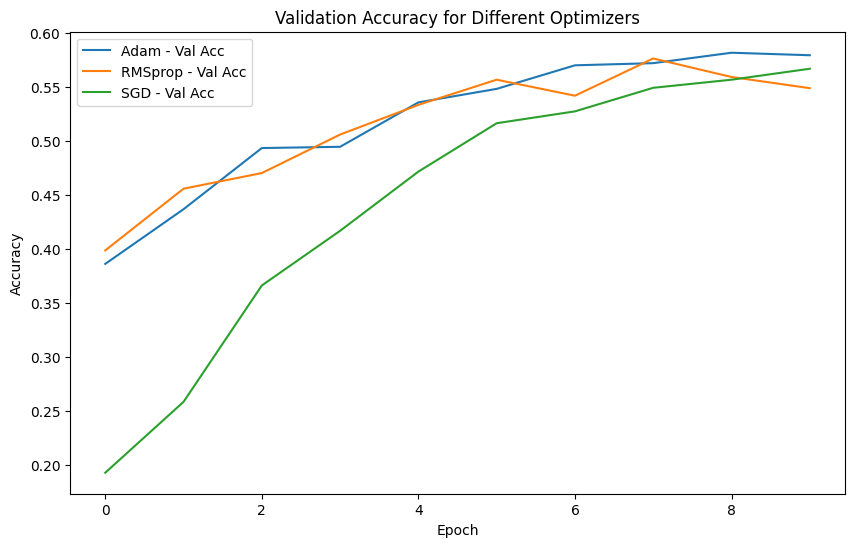

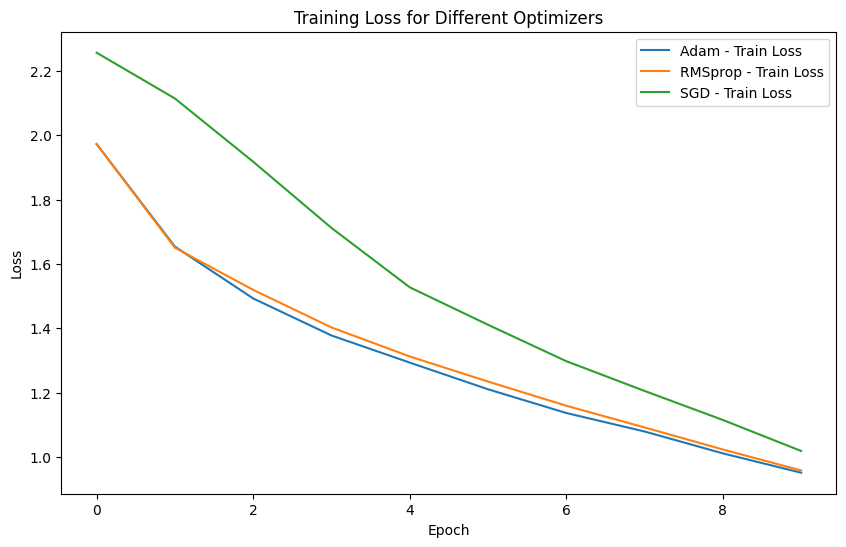

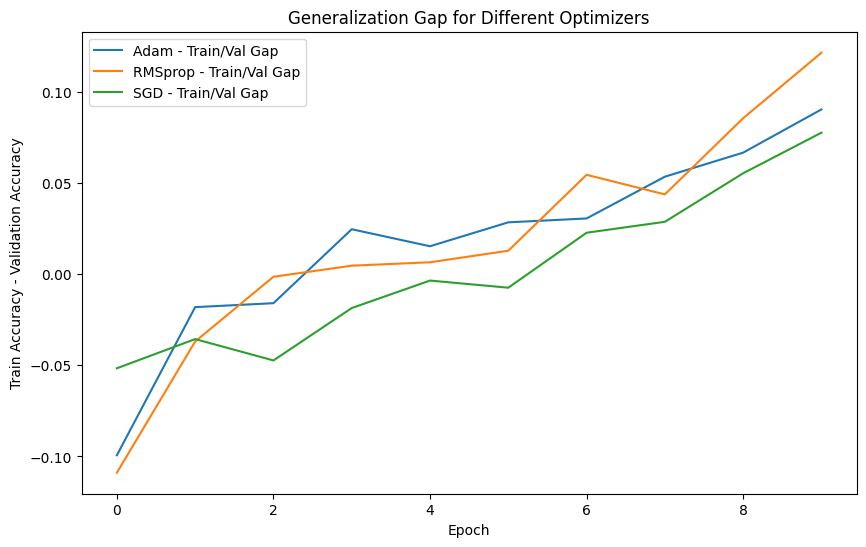

In [26]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{name} - Val Acc")

plt.title("Validation Accuracy for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["train_loss"], label=f"{name} - Train Loss")

plt.title("Training Loss for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    gap = [train - val for train, val in zip(history["train_acc"], history["val_acc"])]
    plt.plot(gap, label=f"{name} - Train/Val Gap")

plt.title("Generalization Gap for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.legend()
plt.show()

### Perform transfer learning using pre-trained models and compare their performance with models trained from scratch

In [13]:
import torch
import torch.nn as nn
from torchvision import models

def get_resnet18_scratch(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_resnet18_pretrained_frozen(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_resnet18_pretrained_finetune(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [14]:
import torch.optim as optim
import pandas as pd

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history

In [15]:
criterion = nn.CrossEntropyLoss()
num_epochs = 10

experiment_configs = [
    {"name": "ResNet18_Scratch", "type": "scratch", "lr": 0.001},
    {"name": "ResNet18_Pretrained_Frozen", "type": "pretrained_frozen", "lr": 0.001},
    {"name": "ResNet18_Pretrained_Finetune", "type": "pretrained_finetune", "lr": 0.0001},
]

results = []
histories = {}

for config in experiment_configs:
    print("\n" + "=" * 70)
    print(f"Running: {config['name']}")

    if config["type"] == "scratch":
        model = get_resnet18_scratch(num_classes)
    elif config["type"] == "pretrained_frozen":
        model = get_resnet18_pretrained_frozen(num_classes)
    elif config["type"] == "pretrained_finetune":
        model = get_resnet18_pretrained_finetune(num_classes)
    else:
        raise ValueError(f"Unknown config type: {config['type']}")

    model = model.to(device)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"]
    )

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    histories[config["name"]] = history

    results.append({
        "model": config["name"],
        "learning_rate": config["lr"],
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    })

results_df = pd.DataFrame(results)


Running: ResNet18_Scratch
Epoch 1/10 | Train Loss: 1.8213, Train Acc: 0.3566 | Val Loss: 1.6942, Val Acc: 0.3958
Epoch 2/10 | Train Loss: 1.4459, Train Acc: 0.4978 | Val Loss: 1.8029, Val Acc: 0.3868
Epoch 3/10 | Train Loss: 1.2636, Train Acc: 0.5680 | Val Loss: 1.4817, Val Acc: 0.5125
Epoch 4/10 | Train Loss: 1.0980, Train Acc: 0.6219 | Val Loss: 1.5532, Val Acc: 0.4945
Epoch 5/10 | Train Loss: 0.9440, Train Acc: 0.6755 | Val Loss: 1.3559, Val Acc: 0.5450
Epoch 6/10 | Train Loss: 0.7674, Train Acc: 0.7332 | Val Loss: 1.4058, Val Acc: 0.5503
Epoch 7/10 | Train Loss: 0.5869, Train Acc: 0.7967 | Val Loss: 1.4146, Val Acc: 0.5697
Epoch 8/10 | Train Loss: 0.4058, Train Acc: 0.8615 | Val Loss: 1.4500, Val Acc: 0.5972
Epoch 9/10 | Train Loss: 0.2778, Train Acc: 0.9052 | Val Loss: 1.4905, Val Acc: 0.6102
Epoch 10/10 | Train Loss: 0.1876, Train Acc: 0.9361 | Val Loss: 1.7136, Val Acc: 0.5947

Running: ResNet18_Pretrained_Frozen
Epoch 1/10 | Train Loss: 1.6265, Train Acc: 0.4436 | Val Loss: 1.

In [16]:
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)

print("Transfer learning comparison:")
display(results_sorted)

best_result = results_sorted.iloc[0]

print("Best configuration:")
display(best_result.to_frame())

Transfer learning comparison:


,model,learning_rate,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
2,ResNet18_Pretrained_Finetune,0.0001,0.077741,0.973417,1.003876,0.774000,0.781167,0.706830
0,ResNet18_Scratch,0.0010,0.187632,0.936125,1.713617,0.594667,0.610167,1.355857
1,ResNet18_Pretrained_Frozen,0.0010,1.419562,0.520792,1.446448,0.523000,0.527000,1.413814


Best configuration:


,2
model,ResNet18_Pretrained_Finetune
learning_rate,0.0001
final_train_loss,0.077741
final_train_acc,0.973417
final_val_loss,1.003876
final_val_acc,0.774
best_val_acc,0.781167
best_val_loss,0.70683


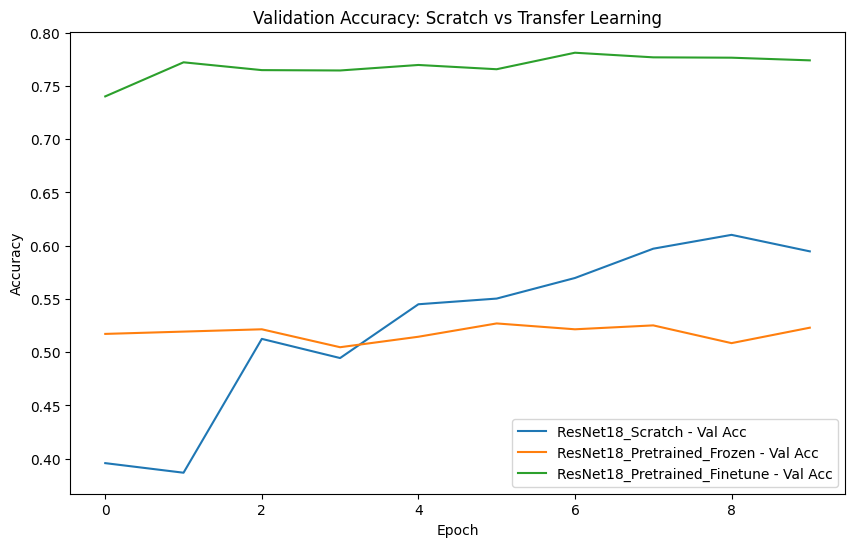

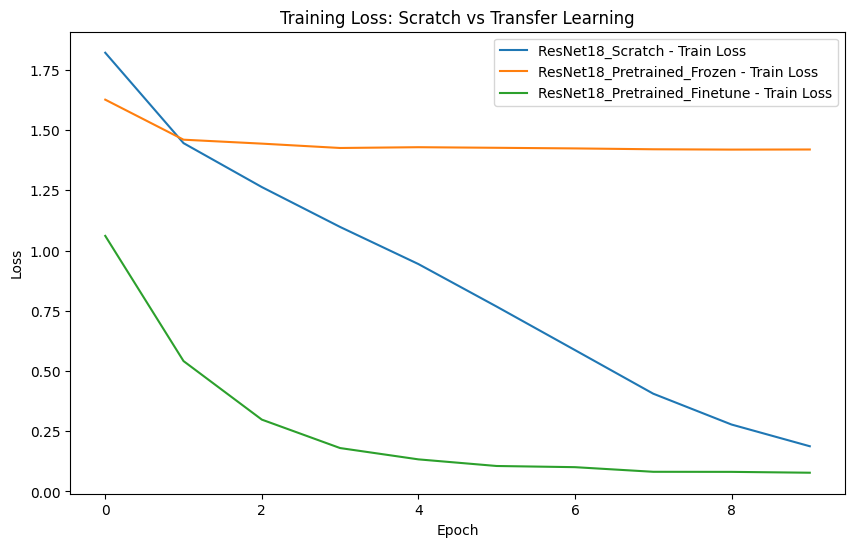

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{name} - Val Acc")

plt.title("Validation Accuracy: Scratch vs Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["train_loss"], label=f"{name} - Train Loss")

plt.title("Training Loss: Scratch vs Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### — Use advanced architectures (e.g., ResNet, DenseNet) and compare their performance with simpler architectures.

In [21]:
import torch
import torch.nn as nn
from torchvision import models

def get_resnet18(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_densenet121(num_classes):
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

In [22]:
models_to_compare = {
    "CNN_3": CNN_3(num_classes),
    "ResNet18": get_resnet18(num_classes),
    "DenseNet121": get_densenet121(num_classes)
}

In [23]:
import torch.optim as optim
import pandas as pd

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history

In [24]:
criterion = nn.CrossEntropyLoss()
num_epochs = 10
learning_rate = 0.001

results = []
histories = {}

for name, model in models_to_compare.items():
    print("\n" + "=" * 70)
    print(f"Training {name}")

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    histories[name] = history

    results.append({
        "model": name,
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    })

results_df = pd.DataFrame(results)


Training CNN_3
Epoch 1/10 | Train Loss: 1.9824, Train Acc: 0.2878 | Val Loss: 1.7205, Val Acc: 0.3928
Epoch 2/10 | Train Loss: 1.6080, Train Acc: 0.4397 | Val Loss: 1.5677, Val Acc: 0.4490
Epoch 3/10 | Train Loss: 1.4231, Train Acc: 0.5033 | Val Loss: 1.3706, Val Acc: 0.5253
Epoch 4/10 | Train Loss: 1.3032, Train Acc: 0.5471 | Val Loss: 1.3640, Val Acc: 0.5305
Epoch 5/10 | Train Loss: 1.2052, Train Acc: 0.5829 | Val Loss: 1.3142, Val Acc: 0.5513
Epoch 6/10 | Train Loss: 1.1135, Train Acc: 0.6141 | Val Loss: 1.2087, Val Acc: 0.5852
Epoch 7/10 | Train Loss: 1.0349, Train Acc: 0.6440 | Val Loss: 1.2710, Val Acc: 0.5728
Epoch 8/10 | Train Loss: 0.9526, Train Acc: 0.6719 | Val Loss: 1.2401, Val Acc: 0.5802
Epoch 9/10 | Train Loss: 0.8776, Train Acc: 0.7007 | Val Loss: 1.1993, Val Acc: 0.5895
Epoch 10/10 | Train Loss: 0.8095, Train Acc: 0.7223 | Val Loss: 1.2200, Val Acc: 0.6012

Training ResNet18
Epoch 1/10 | Train Loss: 1.8185, Train Acc: 0.3631 | Val Loss: 1.6631, Val Acc: 0.4217
Epoch 2

In [25]:
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)

print("Architecture comparison:")
display(results_sorted)

best_result = results_sorted.iloc[0]

print("Best model:")
display(best_result.to_frame())

Architecture comparison:


,model,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
2,DenseNet121,0.411984,0.856958,1.192392,0.671333,0.679000,0.999572
1,ResNet18,0.193440,0.935167,1.785021,0.599833,0.615333,1.166595
0,CNN_3,0.809524,0.722333,1.220008,0.601167,0.601167,1.199323


Best model:


,2
model,DenseNet121
final_train_loss,0.411984
final_train_acc,0.856958
final_val_loss,1.192392
final_val_acc,0.671333
best_val_acc,0.679
best_val_loss,0.999572


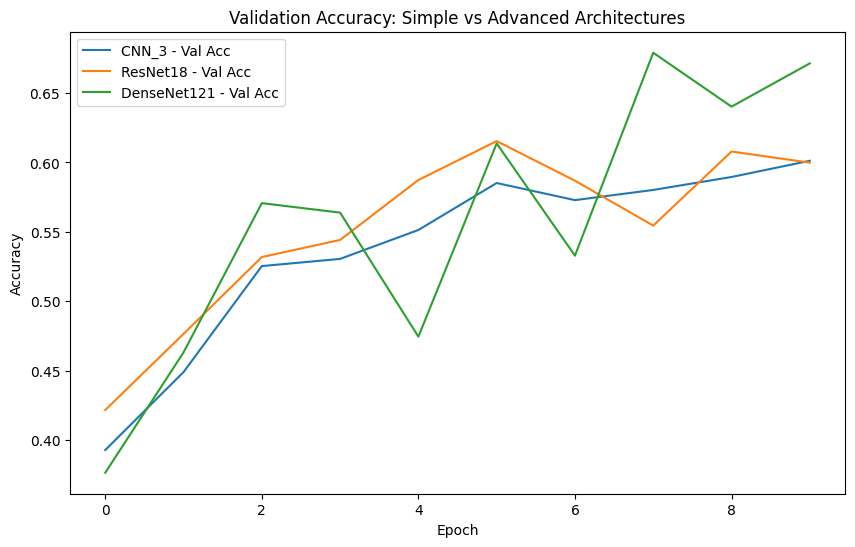

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{name} - Val Acc")

plt.title("Validation Accuracy: Simple vs Advanced Architectures")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

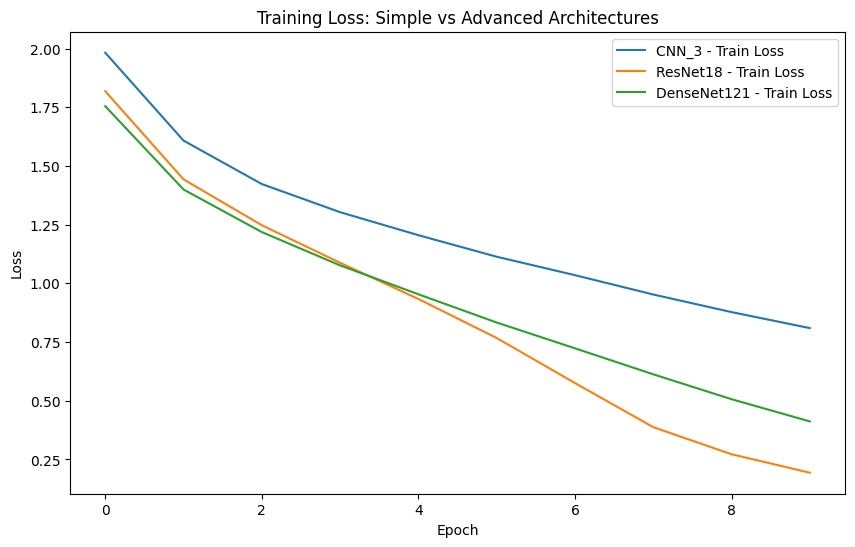

In [27]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["train_loss"], label=f"{name} - Train Loss")

plt.title("Training Loss: Simple vs Advanced Architectures")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### — Use frameworks to automatically search for the best hyperparameters (e.g., Optuna, Hyperopt) and compare their performance with manual tuning.

In [33]:
# =========================
# 1. SETUP
# =========================

# Core
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import itertools
import warnings

# Automatic tuning frameworks
import optuna
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

warnings.filterwarnings("ignore")

# -------------------------
# Tunable model
# -------------------------
class CNN_3_Tunable(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# -------------------------
# Shared training / evaluation helpers
# -------------------------
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    return train_loss, train_acc


def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc


def run_training_config(config, num_epochs=5, verbose=False):
    """
    Train one CNN_3_Tunable configuration and return summary metrics.
    Expects existing notebook variables:
      - make_loaders(batch_size)
      - device
      - num_classes
    """
    lr = config["learning_rate"]
    dropout = config["dropout_rate"]
    batch_size = config["batch_size"]
    optimizer_name = config["optimizer"]

    model = CNN_3_Tunable(
        num_classes=num_classes,
        dropout_rate=dropout
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_val_loss = float("inf")

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        best_val_acc = max(best_val_acc, val_acc)
        best_val_loss = min(best_val_loss, val_loss)

        if verbose:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
            )

    return {
        "config": config,
        "history": history,
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss
    }


# -------------------------
# Search spaces
# -------------------------

# Manual grid search space
manual_learning_rates = [0.001, 0.0003, 0.0001]
manual_dropout_rates = [0.0, 0.3, 0.5]
manual_optimizers = ["Adam", "RMSprop", "SGD"]
manual_batch_sizes = [32, 64]

manual_grid = list(itertools.product(
    manual_learning_rates,
    manual_dropout_rates,
    manual_optimizers,
    manual_batch_sizes
))

print("Manual grid combinations:", len(manual_grid))

# Hyperopt search space
hyperopt_space = {
    "learning_rate": hp.loguniform("learning_rate", np.log(1e-4), np.log(1e-2)),
    "dropout_rate": hp.uniform("dropout_rate", 0.0, 0.5),
    "optimizer": hp.choice("optimizer", ["Adam", "RMSprop", "SGD"]),
    "batch_size": hp.choice("batch_size", [32, 64]),
}

# Shared run settings
NUM_EPOCHS_SEARCH = 5
N_OPTUNA_TRIALS = 15
N_HYPEROPT_EVALS = 15

Manual grid combinations: 54


In [34]:
# =========================
# 2. MODEL TUNING (TRAINING)
# =========================

# -------------------------
# A) Manual Grid Search
# -------------------------
manual_results = []

for i, (lr, dropout, optimizer_name, batch_size) in enumerate(manual_grid, start=1):
    config = {
        "learning_rate": lr,
        "dropout_rate": dropout,
        "optimizer": optimizer_name,
        "batch_size": batch_size
    }

    print(f"\n[Manual] Experiment {i}/{len(manual_grid)}: {config}")

    run_result = run_training_config(
        config=config,
        num_epochs=NUM_EPOCHS_SEARCH,
        verbose=False
    )

    manual_results.append({
        "framework": "Manual Grid Search",
        "learning_rate": lr,
        "dropout_rate": dropout,
        "optimizer": optimizer_name,
        "batch_size": batch_size,
        "final_train_loss": run_result["final_train_loss"],
        "final_train_acc": run_result["final_train_acc"],
        "final_val_loss": run_result["final_val_loss"],
        "final_val_acc": run_result["final_val_acc"],
        "best_val_acc": run_result["best_val_acc"],
        "best_val_loss": run_result["best_val_loss"]
    })

manual_df = pd.DataFrame(manual_results)


# -------------------------
# B) Optuna
# -------------------------
optuna_results = []

def optuna_objective(trial):
    config = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "dropout_rate": trial.suggest_float("dropout_rate", 0.0, 0.5),
        "optimizer": trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"]),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64]),
    }

    run_result = run_training_config(
        config=config,
        num_epochs=NUM_EPOCHS_SEARCH,
        verbose=False
    )

    optuna_results.append({
        "framework": "Optuna",
        "learning_rate": config["learning_rate"],
        "dropout_rate": config["dropout_rate"],
        "optimizer": config["optimizer"],
        "batch_size": config["batch_size"],
        "final_train_loss": run_result["final_train_loss"],
        "final_train_acc": run_result["final_train_acc"],
        "final_val_loss": run_result["final_val_loss"],
        "final_val_acc": run_result["final_val_acc"],
        "best_val_acc": run_result["best_val_acc"],
        "best_val_loss": run_result["best_val_loss"]
    })

    return run_result["best_val_acc"]

optuna_study = optuna.create_study(direction="maximize")
optuna_study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS)

optuna_df = pd.DataFrame(optuna_results)


# -------------------------
# C) Hyperopt
# -------------------------
hyperopt_results = []
hyperopt_trials = Trials()

def hyperopt_objective(params):
    config = {
        "learning_rate": float(params["learning_rate"]),
        "dropout_rate": float(params["dropout_rate"]),
        "optimizer": params["optimizer"],
        "batch_size": int(params["batch_size"]),
    }

    run_result = run_training_config(
        config=config,
        num_epochs=NUM_EPOCHS_SEARCH,
        verbose=False
    )

    hyperopt_results.append({
        "framework": "Hyperopt",
        "learning_rate": config["learning_rate"],
        "dropout_rate": config["dropout_rate"],
        "optimizer": config["optimizer"],
        "batch_size": config["batch_size"],
        "final_train_loss": run_result["final_train_loss"],
        "final_train_acc": run_result["final_train_acc"],
        "final_val_loss": run_result["final_val_loss"],
        "final_val_acc": run_result["final_val_acc"],
        "best_val_acc": run_result["best_val_acc"],
        "best_val_loss": run_result["best_val_loss"]
    })

    return {
        "loss": -run_result["best_val_acc"],   # Hyperopt minimizes
        "status": STATUS_OK
    }

best_hyperopt = fmin(
    fn=hyperopt_objective,
    space=hyperopt_space,
    algo=tpe.suggest,
    max_evals=N_HYPEROPT_EVALS,
    trials=hyperopt_trials,
    rstate=np.random.default_rng(42)
)

hyperopt_df = pd.DataFrame(hyperopt_results)


# -------------------------
# Combine all results
# -------------------------
all_tuning_results_df = pd.concat(
    [manual_df, optuna_df, hyperopt_df],
    ignore_index=True
)

print("Finished all tuning runs.")


[Manual] Experiment 1/54: {'learning_rate': 0.001, 'dropout_rate': 0.0, 'optimizer': 'Adam', 'batch_size': 32}

[Manual] Experiment 2/54: {'learning_rate': 0.001, 'dropout_rate': 0.0, 'optimizer': 'Adam', 'batch_size': 64}

[Manual] Experiment 3/54: {'learning_rate': 0.001, 'dropout_rate': 0.0, 'optimizer': 'RMSprop', 'batch_size': 32}

[Manual] Experiment 4/54: {'learning_rate': 0.001, 'dropout_rate': 0.0, 'optimizer': 'RMSprop', 'batch_size': 64}

[Manual] Experiment 5/54: {'learning_rate': 0.001, 'dropout_rate': 0.0, 'optimizer': 'SGD', 'batch_size': 32}

[Manual] Experiment 6/54: {'learning_rate': 0.001, 'dropout_rate': 0.0, 'optimizer': 'SGD', 'batch_size': 64}

[Manual] Experiment 7/54: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'optimizer': 'Adam', 'batch_size': 32}

[Manual] Experiment 8/54: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'optimizer': 'Adam', 'batch_size': 64}

[Manual] Experiment 9/54: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'optimizer': 'RMSprop', 'ba

[I 2026-04-05 15:06:31,411] A new study created in memory with name: no-name-ff8b25b0-d08c-41d3-af55-10f770dea728
[I 2026-04-05 15:09:01,789] Trial 0 finished with value: 0.4483333333333333 and parameters: {'learning_rate': 0.007441304208941368, 'dropout_rate': 0.3288420727841988, 'optimizer': 'SGD', 'batch_size': 32}. Best is trial 0 with value: 0.4483333333333333.
[I 2026-04-05 15:11:33,187] Trial 1 finished with value: 0.47633333333333333 and parameters: {'learning_rate': 0.0003457316611222872, 'dropout_rate': 0.23924103741429587, 'optimizer': 'RMSprop', 'batch_size': 32}. Best is trial 1 with value: 0.47633333333333333.
[I 2026-04-05 15:14:04,443] Trial 2 finished with value: 0.5055 and parameters: {'learning_rate': 0.0020799919457912047, 'dropout_rate': 0.4013895994277781, 'optimizer': 'RMSprop', 'batch_size': 64}. Best is trial 2 with value: 0.5055.
[I 2026-04-05 15:16:35,348] Trial 3 finished with value: 0.38566666666666666 and parameters: {'learning_rate': 0.000102994883415612,

100%|██████████| 15/15 [37:33<00:00, 150.24s/trial, best loss: -0.5191666666666667]
Finished all tuning runs.


In [35]:
# =========================
# 3. EVALUATIONS
# =========================

# -------------------------
# A) Full results sorted
# -------------------------
results_sorted = all_tuning_results_df.sort_values(by="best_val_acc", ascending=False)
display(results_sorted)

# -------------------------
# B) Best result per framework
# -------------------------
best_per_framework = (
    all_tuning_results_df.sort_values(by="best_val_acc", ascending=False)
    .groupby("framework", as_index=False)
    .first()
)

print("Best result per framework:")
display(best_per_framework)

# -------------------------
# C) Average performance per framework
# -------------------------
framework_summary = (
    all_tuning_results_df
    .groupby("framework")[["best_val_acc", "final_val_acc", "final_val_loss"]]
    .mean()
    .sort_values(by="best_val_acc", ascending=False)
)

print("Average performance per framework:")
display(framework_summary)

# -------------------------
# D) Best overall configuration
# -------------------------
best_overall = results_sorted.iloc[0]
print("Best overall configuration:")
display(best_overall.to_frame())

# -------------------------
# E) Compact comparison table
# -------------------------
comparison_table = best_per_framework[[
    "framework", "learning_rate", "dropout_rate", "optimizer", "batch_size", "best_val_acc"
]].sort_values(by="best_val_acc", ascending=False)

print("Framework comparison:")
display(comparison_table)

# -------------------------
# F) Optional: save all results
# -------------------------
all_tuning_results_df.to_csv("automatic_tuning_framework_comparison.csv", index=False)
print("Saved results to automatic_tuning_framework_comparison.csv")

,framework,learning_rate,dropout_rate,optimizer,batch_size,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
65,Optuna,0.001237,0.177686,RMSprop,32,1.311717,0.541417,1.275438,0.555667,0.555667,1.275438
3,Manual Grid Search,0.001000,0.000000,RMSprop,64,1.269700,0.559417,1.284315,0.551000,0.551000,1.284315
9,Manual Grid Search,0.001000,0.300000,RMSprop,64,1.364923,0.527125,1.320956,0.543500,0.543500,1.320956
2,Manual Grid Search,0.001000,0.000000,RMSprop,32,1.299066,0.552458,1.311127,0.540833,0.540833,1.311127
66,Optuna,0.001145,0.225813,RMSprop,32,1.343548,0.534708,1.314835,0.540833,0.540833,1.314835
...,...,...,...,...,...,...,...,...,...,...,...
46,Manual Grid Search,0.000100,0.300000,SGD,32,2.302055,0.103250,2.301914,0.111833,0.111833,2.301914
47,Manual Grid Search,0.000100,0.300000,SGD,64,2.302519,0.105208,2.302480,0.105333,0.105333,2.302480
53,Manual Grid Search,0.000100,0.500000,SGD,64,2.302807,0.102542,2.302712,0.098167,0.101500,2.302712
52,Manual Grid Search,0.000100,0.500000,SGD,32,2.302240,0.104625,2.301917,0.100167,0.100333,2.301917


Best result per framework:


,framework,learning_rate,dropout_rate,optimizer,batch_size,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
0,Hyperopt,0.001739,0.441963,Adam,64,1.380968,0.520250,1.364568,0.519167,0.519167,1.364568
1,Manual Grid Search,0.001000,0.000000,RMSprop,64,1.269700,0.559417,1.284315,0.551000,0.551000,1.284315
2,Optuna,0.001237,0.177686,RMSprop,32,1.311717,0.541417,1.275438,0.555667,0.555667,1.275438


Average performance per framework:


,best_val_acc,final_val_acc,final_val_loss
framework,,,
Optuna,0.443911,0.443267,1.583682
Hyperopt,0.359967,0.358133,1.793003
Manual Grid Search,0.350994,0.350046,1.802440


Best overall configuration:


,65
framework,Optuna
learning_rate,0.001237
dropout_rate,0.177686
optimizer,RMSprop
batch_size,32
final_train_loss,1.311717
final_train_acc,0.541417
final_val_loss,1.275438
final_val_acc,0.555667
best_val_acc,0.555667


Framework comparison:


,framework,learning_rate,dropout_rate,optimizer,batch_size,best_val_acc
2,Optuna,0.001237,0.177686,RMSprop,32,0.555667
1,Manual Grid Search,0.001000,0.000000,RMSprop,64,0.551000
0,Hyperopt,0.001739,0.441963,Adam,64,0.519167


Saved results to automatic_tuning_framework_comparison.csv


### — Experiment with data augmentation techniques to improve model generalization (e.g., random cropping, horizontal flipping, color jittering).

In [36]:
# =========================
# 1. SETUP
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# -------------------------
# Paths and basic settings
# -------------------------
IMG_SIZE = (64, 64)   # or (128, 128) if you want the larger version
BATCH_SIZE = 32
NUM_EPOCHS = 10

train_dir = "icosimal_img_class_03/data_uniform_224_224_sets/train"
val_dir = "icosimal_img_class_03/data_uniform_224_224_sets/validate"

# -------------------------
# Augmentation configurations
# -------------------------
augmentation_configs = {
    "No_Augmentation": transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor()
    ]),

    "Basic_Augmentation": transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ToTensor()
    ]),

    "Strong_Augmentation": transforms.Compose([
        transforms.Resize((72, 72)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.RandomRotation(15),
        transforms.ToTensor()
    ])
}

# Validation should stay clean / unchanged
val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

# -------------------------
# Create validation dataset once
# -------------------------
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
num_classes = len(val_dataset.classes)
class_names = val_dataset.classes

print("Classes:", class_names)
print("Number of classes:", num_classes)

def make_loaders_with_augmentation(train_transform, batch_size=BATCH_SIZE):
    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader


# -------------------------
# Reuse your CNN_3 model
# -------------------------
class CNN_3(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# -------------------------
# Shared train / evaluate helpers
# -------------------------
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    return train_loss, train_acc


def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc

Classes: ['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']
Number of classes: 10


In [37]:
# =========================
# 2. MODEL TUNING (TRAINING)
# =========================

criterion = nn.CrossEntropyLoss()
learning_rate = 0.001

results = []
histories = {}

for aug_name, train_transform in augmentation_configs.items():
    print("\n" + "=" * 70)
    print(f"Training with augmentation: {aug_name}")

    train_loader, val_loader = make_loaders_with_augmentation(
        train_transform=train_transform,
        batch_size=BATCH_SIZE
    )

    model = CNN_3(num_classes=num_classes, dropout_rate=0.0).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_val_loss = float("inf")

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        best_val_acc = max(best_val_acc, val_acc)
        best_val_loss = min(best_val_loss, val_loss)

        print(
            f"Epoch {epoch+1}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    histories[aug_name] = history

    results.append({
        "augmentation": aug_name,
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss
    })

results_df = pd.DataFrame(results)
print("Finished augmentation experiments.")


Training with augmentation: No_Augmentation
Epoch 1/10 | Train Loss: 2.0581, Train Acc: 0.2518 | Val Loss: 1.8312, Val Acc: 0.3517
Epoch 2/10 | Train Loss: 1.6800, Train Acc: 0.4106 | Val Loss: 1.6320, Val Acc: 0.4293
Epoch 3/10 | Train Loss: 1.5044, Train Acc: 0.4722 | Val Loss: 1.4629, Val Acc: 0.4923
Epoch 4/10 | Train Loss: 1.3956, Train Acc: 0.5102 | Val Loss: 1.3979, Val Acc: 0.5202
Epoch 5/10 | Train Loss: 1.3006, Train Acc: 0.5480 | Val Loss: 1.3382, Val Acc: 0.5397
Epoch 6/10 | Train Loss: 1.2168, Train Acc: 0.5776 | Val Loss: 1.2786, Val Acc: 0.5580
Epoch 7/10 | Train Loss: 1.1471, Train Acc: 0.6047 | Val Loss: 1.2837, Val Acc: 0.5605
Epoch 8/10 | Train Loss: 1.0725, Train Acc: 0.6274 | Val Loss: 1.2688, Val Acc: 0.5670
Epoch 9/10 | Train Loss: 1.0129, Train Acc: 0.6472 | Val Loss: 1.2949, Val Acc: 0.5722
Epoch 10/10 | Train Loss: 0.9357, Train Acc: 0.6753 | Val Loss: 1.3678, Val Acc: 0.5482

Training with augmentation: Basic_Augmentation
Epoch 1/10 | Train Loss: 2.0098, Tra

,augmentation,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
1,Basic_Augmentation,1.114098,0.611792,1.200623,0.591000,0.591000,1.197255
2,Strong_Augmentation,1.280599,0.552250,1.207728,0.581500,0.581500,1.207728
0,No_Augmentation,0.935703,0.675333,1.367829,0.548167,0.572167,1.268815


Best augmentation setting:


,1
augmentation,Basic_Augmentation
final_train_loss,1.114098
final_train_acc,0.611792
final_val_loss,1.200623
final_val_acc,0.591
best_val_acc,0.591
best_val_loss,1.197255


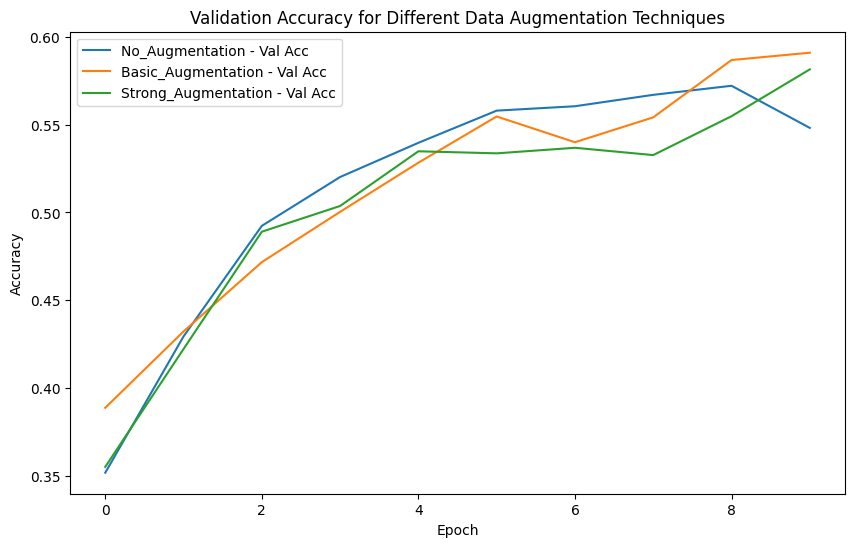

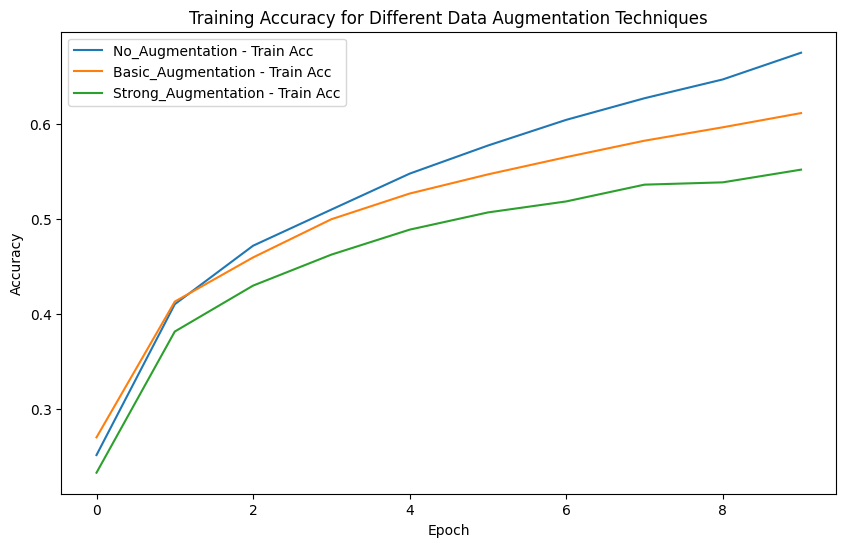

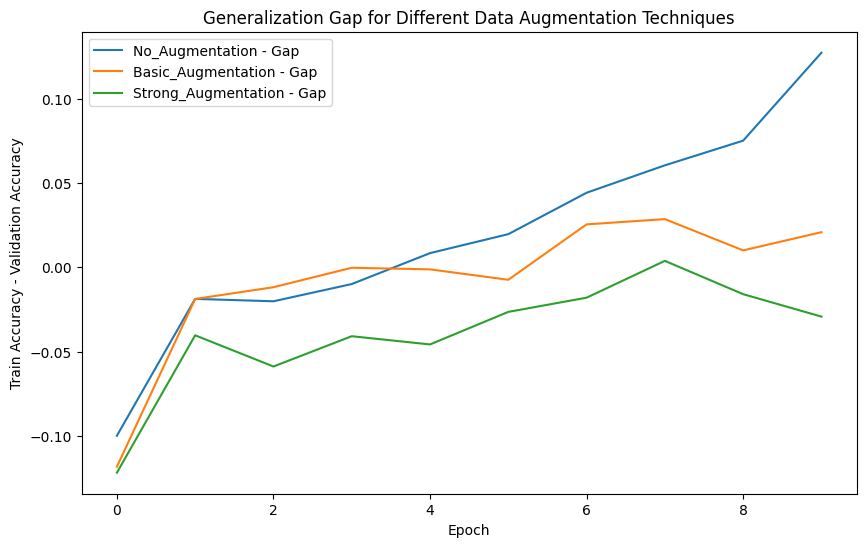

Saved results to augmentation_comparison_results.csv


In [38]:
# =========================
# 3. EVALUATIONS
# =========================

# -------------------------
# A) Full result table
# -------------------------
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)
display(results_sorted)

# -------------------------
# B) Best augmentation setting
# -------------------------
best_result = results_sorted.iloc[0]
print("Best augmentation setting:")
display(best_result.to_frame())

# -------------------------
# C) Validation accuracy curves
# -------------------------
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{name} - Val Acc")

plt.title("Validation Accuracy for Different Data Augmentation Techniques")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -------------------------
# D) Training accuracy curves
# -------------------------
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["train_acc"], label=f"{name} - Train Acc")

plt.title("Training Accuracy for Different Data Augmentation Techniques")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -------------------------
# E) Generalization gap
# -------------------------
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    gap = [train - val for train, val in zip(history["train_acc"], history["val_acc"])]
    plt.plot(gap, label=f"{name} - Gap")

plt.title("Generalization Gap for Different Data Augmentation Techniques")
plt.xlabel("Epoch")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.legend()
plt.show()

# -------------------------
# F) Optional save
# -------------------------
results_df.to_csv("augmentation_comparison_results.csv", index=False)
print("Saved results to augmentation_comparison_results.csv")

### — Manually inspect misclassifications of your best model to identify mis-labelled samples in the dataset. Analyze their impact on model performance (i.e. when they are removed from the training set, when they are removed from the validation set, when they are kept in both sets). If you do so, provide logs of the mis-labelled images.

In [43]:
# =========================
# 1. SETUP
# =========================

import torch
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

# Reuse:
# - best_model (your best trained model)
# - val_loader
# - train_loader
# - device
# - class_names
best_model = model
best_model.eval()


# -------------------------
# Collect misclassifications
# -------------------------
def collect_misclassifications(model, loader, dataset_type="val"):
    misclassified = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            for i in range(len(images)):
                if preds[i] != labels[i]:
                    misclassified.append({
                        "dataset": dataset_type,
                        "true_label": labels[i].item(),
                        "pred_label": preds[i].item()
                    })

    return misclassified

,dataset,true_label,pred_label
0,val,0,2
1,val,0,2
2,val,0,2
3,val,0,2
4,val,0,2


Saved misclassified_samples.csv


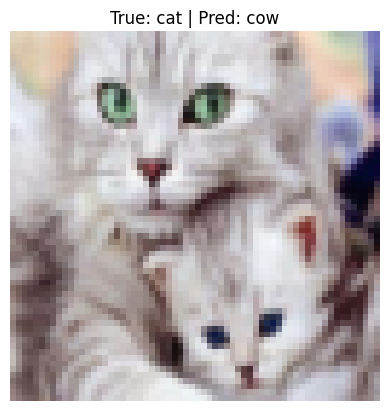

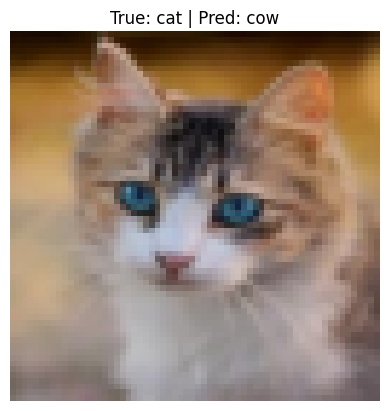

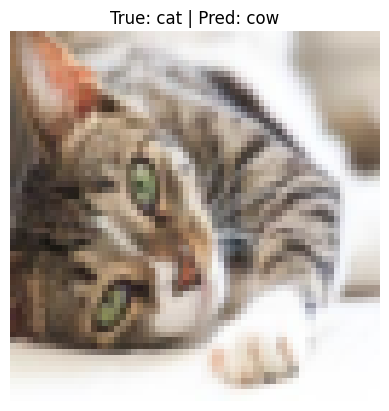

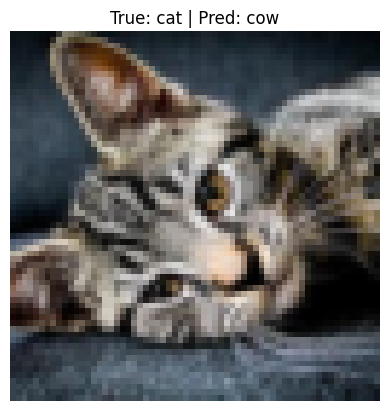

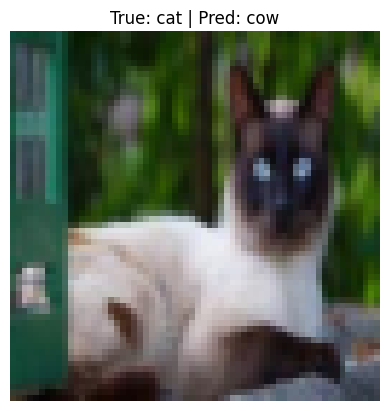

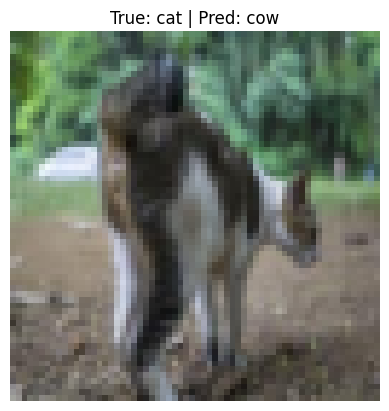

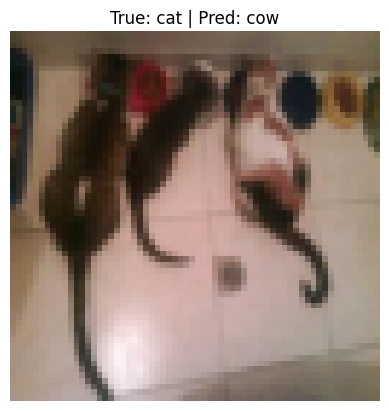

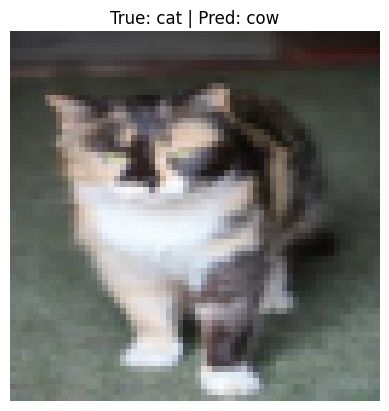

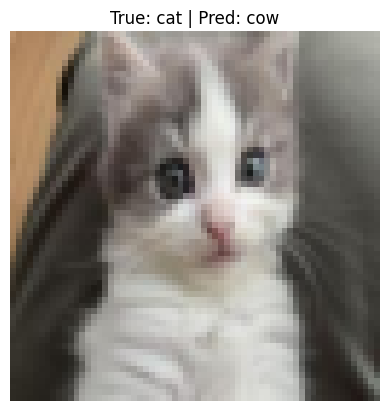

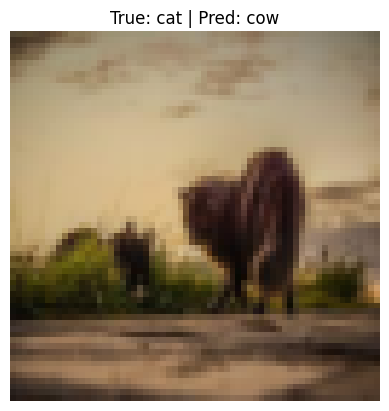

KeyboardInterrupt: 

In [44]:
# =========================
# 2A. COLLECT MISCLASSIFICATIONS
# =========================

val_misclassified = collect_misclassifications(best_model, val_loader, "val")
train_misclassified = collect_misclassifications(best_model, train_loader, "train")

misclassified_df = pd.DataFrame(val_misclassified + train_misclassified)

display(misclassified_df.head())

# Save log
misclassified_df.to_csv("misclassified_samples.csv", index=False)
print("Saved misclassified_samples.csv")

# =========================
# 2B. VISUAL INSPECTION
# =========================

def show_misclassified_images(model, loader, class_names, max_images=10):
    model.eval()
    count = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            for i in range(len(images)):
                if preds[i] != labels[i]:
                    img = images[i].cpu().permute(1, 2, 0)

                    plt.imshow(img)
                    plt.title(
                        f"True: {class_names[labels[i]]} | Pred: {class_names[preds[i]]}"
                    )
                    plt.axis("off")
                    plt.show()

                    count += 1
                    if count >= max_images:
                        return

# Show examples
show_misclassified_images(best_model, val_loader, class_names, max_images=10)

# =========================
# 2C. MANUAL LABEL CORRECTION LIST
# =========================

# Example (you must fill this manually after inspection)
mislabeled_indices = [
    # example indices you identified manually
    # 12, 45, 102, ...
]

# Save log
pd.DataFrame({"mislabeled_indices": mislabeled_indices}).to_csv(
    "mislabeled_samples_manual.csv", index=False
)

# =========================
# 2D. DATASET FILTERING
# =========================

from torch.utils.data import Subset

def remove_indices(dataset, indices_to_remove):
    keep_indices = [i for i in range(len(dataset)) if i not in indices_to_remove]
    return Subset(dataset, keep_indices)


# Original datasets
train_dataset = train_loader.dataset
val_dataset = val_loader.dataset

# Modified datasets
train_clean = remove_indices(train_dataset, mislabeled_indices)
val_clean = remove_indices(val_dataset, mislabeled_indices)

train_loader_clean = torch.utils.data.DataLoader(train_clean, batch_size=32, shuffle=True)
val_loader_clean = torch.utils.data.DataLoader(val_clean, batch_size=32, shuffle=False)

# =========================
# 2E. RE-TRAIN EXPERIMENTS
# =========================

def run_experiment(train_loader, val_loader, label):
    model = CNN_3(num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    history = []

    for epoch in range(10):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history.append({
            "epoch": epoch,
            "train_acc": train_acc,
            "val_acc": val_acc
        })

    final_val_acc = history[-1]["val_acc"]

    return final_val_acc


results = []

# 1. baseline
results.append({
    "setup": "original_data",
    "val_acc": run_experiment(train_loader, val_loader, "baseline")
})

# 2. remove from training
results.append({
    "setup": "train_cleaned",
    "val_acc": run_experiment(train_loader_clean, val_loader, "train_cleaned")
})

# 3. remove from validation
results.append({
    "setup": "val_cleaned",
    "val_acc": run_experiment(train_loader, val_loader_clean, "val_cleaned")
})

# 4. remove from both
results.append({
    "setup": "both_cleaned",
    "val_acc": run_experiment(train_loader_clean, val_loader_clean, "both_cleaned")
})

results_df = pd.DataFrame(results)
display(results_df)

In [ ]:
# =========================
# 3. EVALUATIONS
# =========================

results_sorted = results_df.sort_values(by="val_acc", ascending=False)
display(results_sorted)

### — Perform error analysis to identify common misclassifications.